### In-plane axial force distribution highlighting extreme edge load concentration

The axial force per unit width Nx is analytically derived from the second partial derivative of the Airy stress function $F$ with respect to the y-coordinate. 
The resulting equation maps the physical transition from a uniform pre-buckling state ($-Px/a$) to a highly concentrated parabolic post-buckling stress state.

Based on Kassapoglou [@Kassapoglou2013].

NOTE: The formula computationally calculates the absolute magnitude of the distributed compressive force.

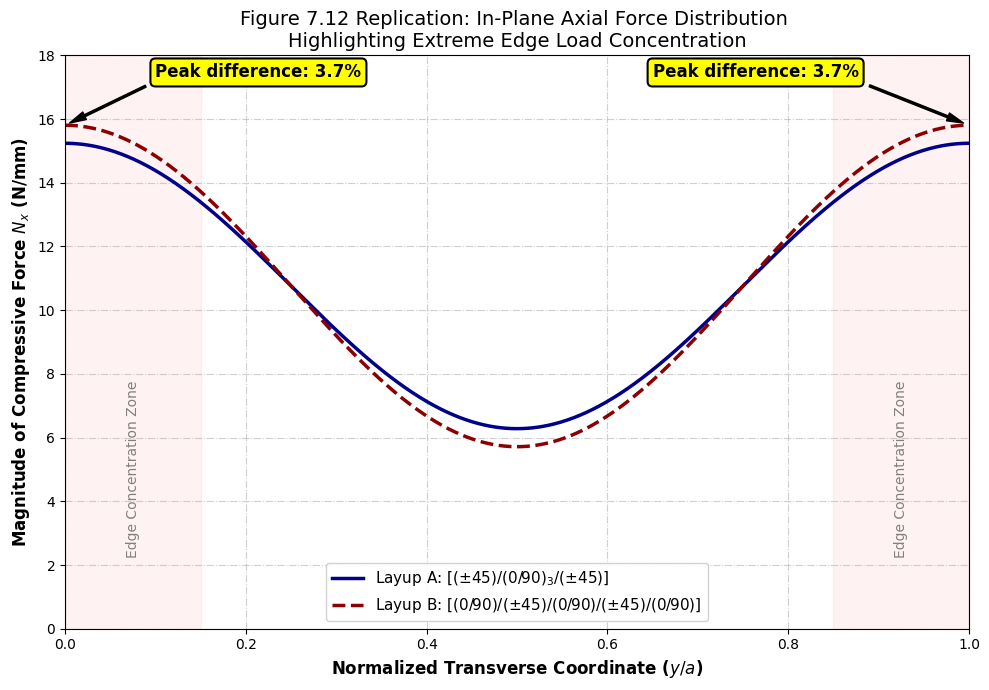

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Geometrical and Applied Load Definitions
# ==========================================
Px = 2152.0  # Total ultimate applied compressive force in Newtons
a = 200.0    # Panel width and length dimensions in mm

# ==========================================
# Constitutive Parameters Derived from Compatibility
# ==========================================
# The Airy stress function compatibility constants (K02) directly govern the amplitude 
# of the non-linear in-plane stress redistribution caused by out-of-plane geometric curvature.
K02_A = 4538.78   # Computed compatibility coefficient for Layup A
K02_B = 5112.312  # Computed compatibility coefficient for Layup B

# Define the continuous transverse spatial domain normalized from 0 to 1
y = np.linspace(0, a, 1000)
y_normalized = y / a

Nx_A_magnitude = (Px / a) + (4.0 * np.pi**2 / a**2) * K02_A * np.cos(2.0 * np.pi * y / a)
Nx_B_magnitude = (Px / a) + (4.0 * np.pi**2 / a**2) * K02_B * np.cos(2.0 * np.pi * y / a)

# ==========================================
# High-Fidelity Visualization Generation
# ==========================================
plt.figure(figsize=(10, 7))

# Plotting the severe stress distributions for both layups
plt.plot(y_normalized, Nx_A_magnitude, label='Layup A: $[(\pm 45)/(0/90)_3/(\pm 45)]$', 
         linewidth=2.5, color='darkblue')
plt.plot(y_normalized, Nx_B_magnitude, label='Layup B: $[(0/90)/(\pm 45)/(0/90)/(\pm 45)/(0/90)]$', 
         linewidth=2.5, color='darkred', linestyle='--')

# Annotating the maximum terminal stress disparity at the panel edges
max_A = np.max(Nx_A_magnitude)
max_B = np.max(Nx_B_magnitude)
percent_diff = ((max_B - max_A) / max_A) * 100

plt.annotate(f'Peak difference: {percent_diff:.1f}%', 
             xy=(0.0, max_B), xytext=(0.1, max_B + 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
             fontsize=12, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1.5))

plt.annotate(f'Peak difference: {percent_diff:.1f}%', 
             xy=(1.0, max_B), xytext=(0.65, max_B + 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
             fontsize=12, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1.5))

# Structuring formatting for engineering report integration
plt.xlabel('Normalized Transverse Coordinate ($y / a$)', fontsize=12, fontweight='bold')
plt.ylabel('Magnitude of Compressive Force $N_x$ (N/mm)', fontsize=12, fontweight='bold')
plt.title('Figure 7.12 Replication: In-Plane Axial Force Distribution \nHighlighting Extreme Edge Load Concentration', fontsize=14)
plt.grid(True, linestyle='-.', alpha=0.6)
plt.legend(loc='lower center', fontsize=11, framealpha=0.9)
plt.xlim(0, 1.0)
plt.ylim(0, 18)

# Shading the effective width support regions to visually emphasize the load concentration
plt.axvspan(0, 0.15, color='red', alpha=0.05)
plt.axvspan(0.85, 1.0, color='red', alpha=0.05)
plt.text(0.075, 5, 'Edge Concentration Zone', rotation=90, va='center', ha='center', color='gray', fontsize=10)
plt.text(0.925, 5, 'Edge Concentration Zone', rotation=90, va='center', ha='center', color='gray', fontsize=10)

plt.tight_layout()
plt.show()